# How does beating visualize in wavelet spectrogram?

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
path.append('../signals/')

import wavelet_funcs as wf
import signals as sg

In [9]:
from scipy.signal import periodogram

## Beating cosine, no noise

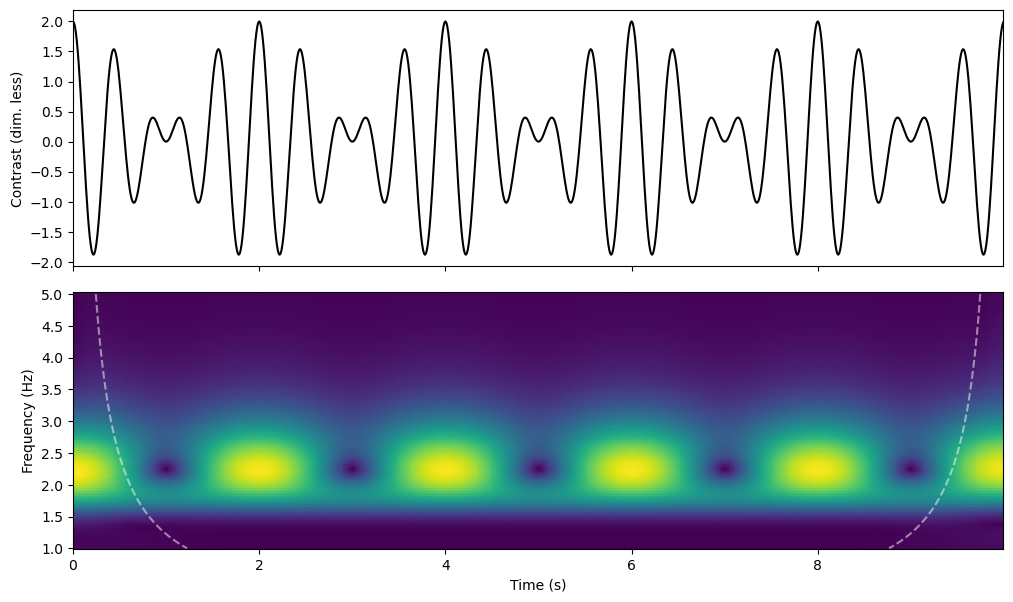

In [94]:
f1 = 2 # Hz
df = 0.5 # Hz
t,s = sg.sum_of_cosines(10, f1, f1+df, 100)

_, (ax,ax1) = wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, method='fft', show_smoothed=False)

[Text(0.5, 0, 'Frequency (Hz)'), Text(0, 0.5, 'Periodogram value (1/Hz)')]

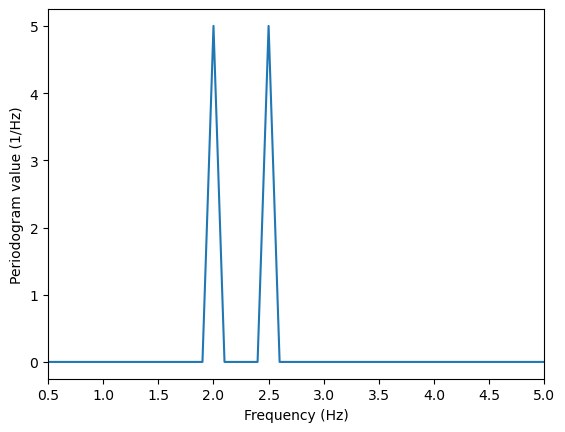

In [96]:
plt.plot(*periodogram(s, fs=100))
plt.xlim(0.5,5)
plt.gca().set(xlabel='Frequency (Hz)', ylabel='Periodogram value (1/Hz)')

## Beating cosine with noise

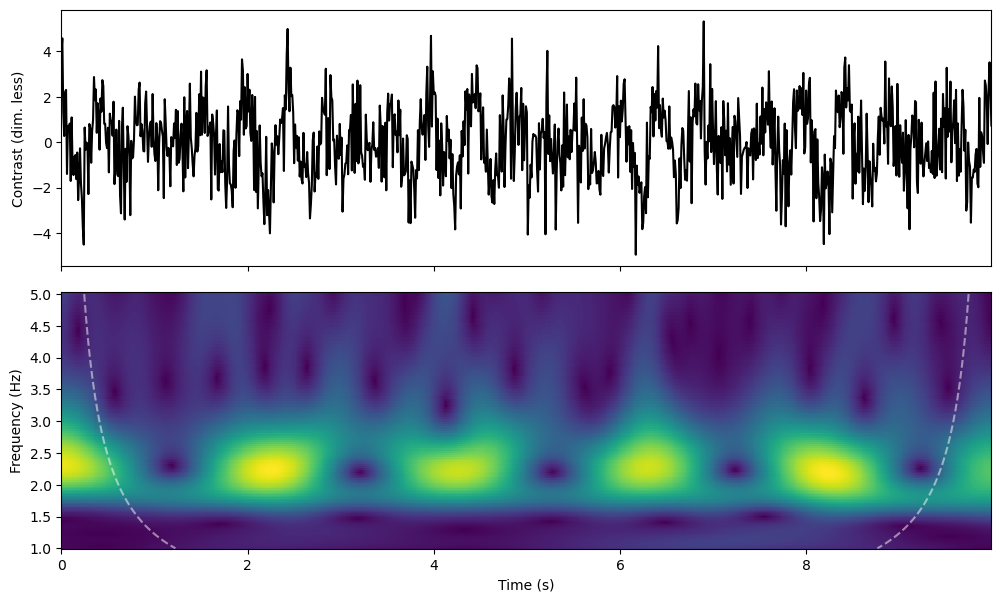

In [140]:
f1 = 2 # Hz
df = 0.5 # Hz
t,s = sg.sum_of_cosines(10, f1, f1+df, 100, phase1=np.pi/5)
s = s + np.random.randn(s.size)*1.3

_, (ax,ax1) = wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, method='fft', show_smoothed=False, precision=16)

### Spectrogram of beating signal looks like a chain of rings: The ridge is not a continuous band, but it splits into two low-amplitude lobes, which then rejoin. Splitting and rejoining continues at twice the beating frequency, i.e. 1/(delta frequency), where delta frequency is the frequency difference between the two oscillations summing up into the beating signal

[Text(0.5, 0, 'Frequency (Hz)'), Text(0, 0.5, 'Periodogram value (1/Hz)')]

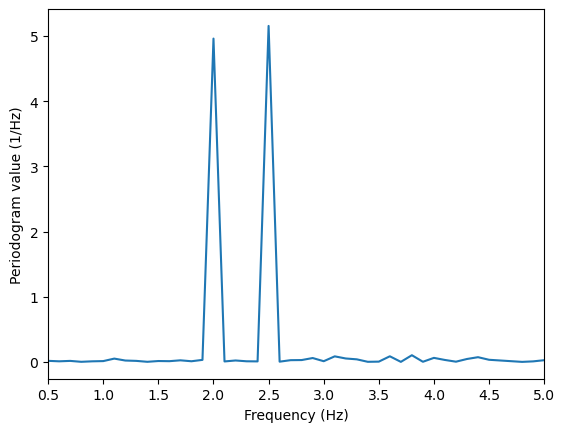

In [142]:
plt.plot(*periodogram(s, fs=100))
plt.xlim(0.5,5)
plt.gca().set(xlabel='Frequency (Hz)', ylabel='Periodogram value (1/Hz)')